## Task#1: Unsharp Masking

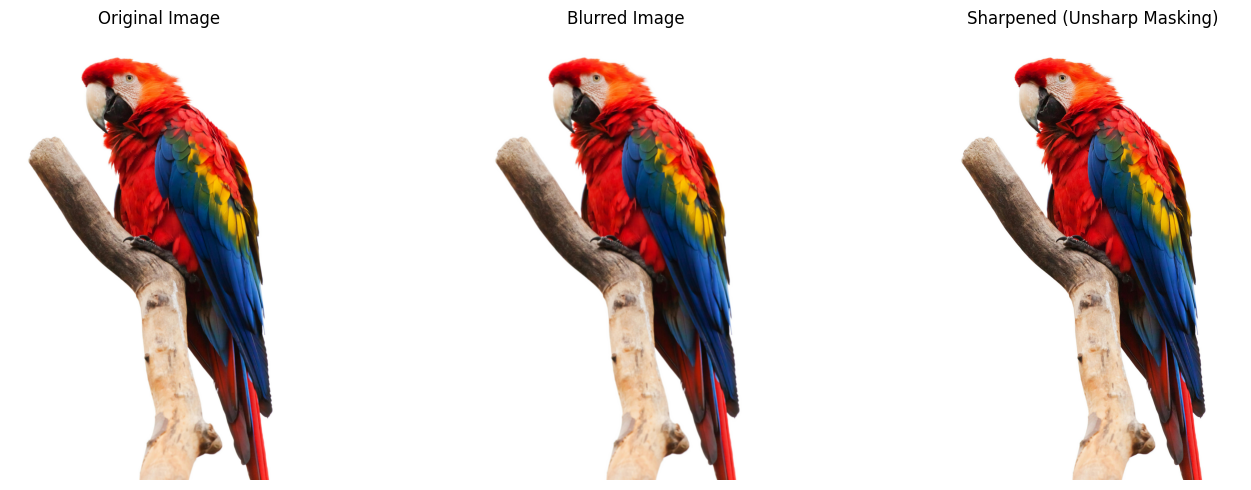

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(r'Pics\\Parrot_RGB.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2

# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image_float)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## Task#2: Convolve Image with 7x7 Box Filter

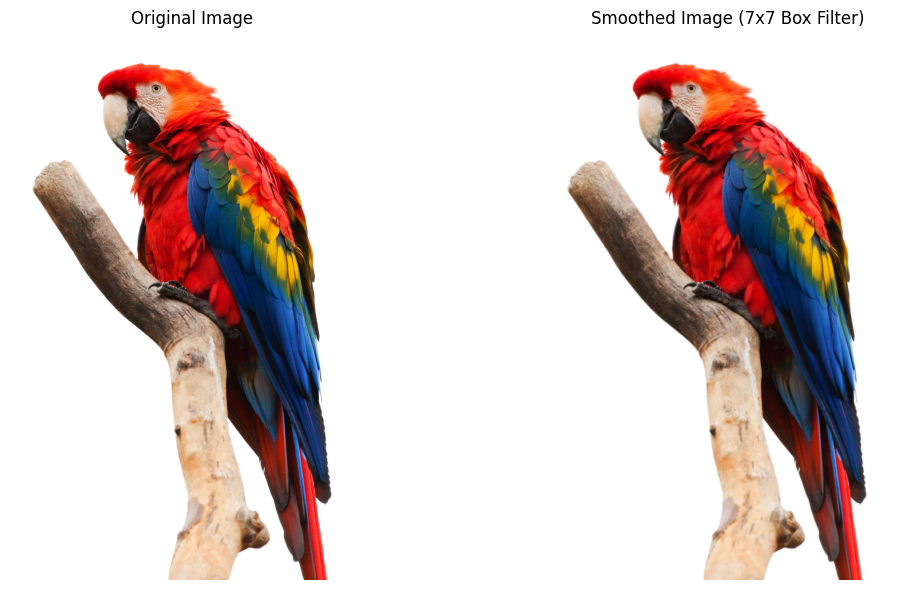

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(r'Pics\\Parrot_RGB.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a 7x7 box filter (averaging filter)
box_filter = np.ones((7, 7), np.float32) / 49

# Apply the box filter using convolution
smoothed = cv2.filter2D(image, -1, box_filter)

# Display original and smoothed images side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(smoothed)
ax[1].set_title("Smoothed Image (7x7 Box Filter)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Task#3: Apply 5x5 and 21x21 Gaussian Filters

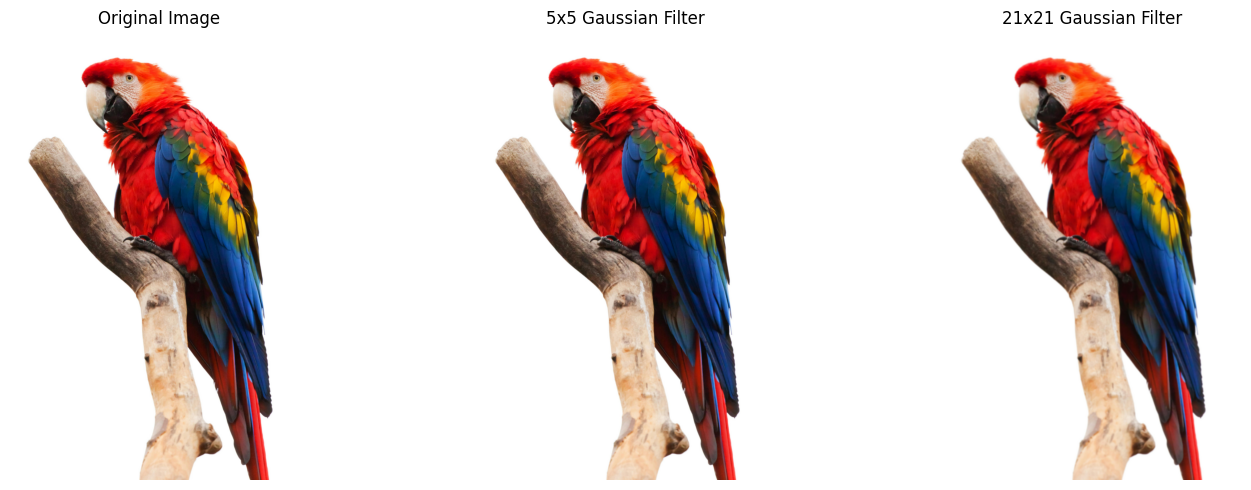

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(r'Pics\\Parrot_RGB.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply 5x5 Gaussian filter
gaussian_5x5 = cv2.GaussianBlur(image, (5, 5), 0)

# Apply 21x21 Gaussian filter
gaussian_21x21 = cv2.GaussianBlur(image, (21, 21), 0)

# Display original and filtered images side by side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(gaussian_5x5)
ax[1].set_title("5x5 Gaussian Filter")
ax[1].axis("off")

ax[2].imshow(gaussian_21x21)
ax[2].set_title("21x21 Gaussian Filter")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## Task#4: Apply 3x3 Laplacian Filter for Sharpening

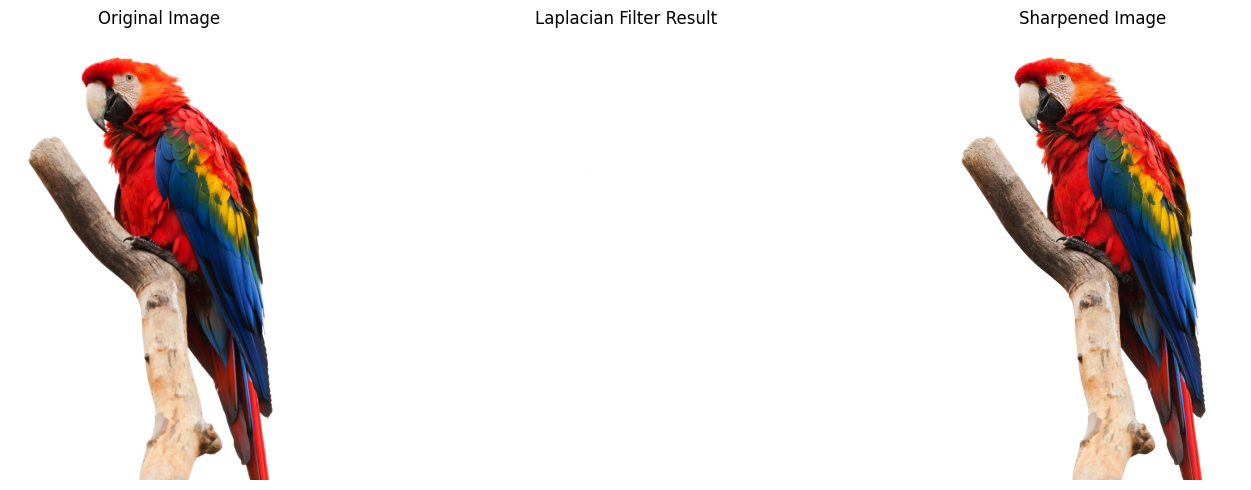

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image
image = cv2.imread(r'Pics\\Parrot_RGB.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 2: Convert image to float32
image_float = image.astype(np.float32) / 255.0

# Step 3: Use the cv2.Laplacian() function (3x3 kernel)
# Convert to grayscale for Laplacian
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
laplacian = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)

# For color image, apply Laplacian to each channel
laplacian_color = np.zeros_like(image_float)
for i in range(3):
    laplacian_color[:, :, i] = cv2.Laplacian(image_float[:, :, i], cv2.CV_32F, ksize=3)

# Step 4: Sharpen the image
sharpened = np.clip(image_float - laplacian_color, 0, 1)

# Step 5: Plot the original, Laplacian, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image_float)
ax[0].set_title("Original Image")
ax[0].axis("off")

# Display Laplacian (normalized for visualization)
laplacian_display = np.clip(laplacian_color - laplacian_color.min(), 0, 1)
laplacian_display = laplacian_display / (laplacian_display.max() + 1e-10)
ax[1].imshow(laplacian_display)
ax[1].set_title("Laplacian Filter Result")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened Image")
ax[2].axis("off")

plt.tight_layout()
plt.show()